In [1]:
import numpy as np

import torch
import torch.nn as nn

from utils import InMemDataLoader, draw_images

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

In [ ]:
IMG_WIDTH = 48

CLEAN_DATASET_FILENAME = "teddy_bear.npy"
CLEAN_DATASET_PATH = f"clean_datasets/{CLEAN_DATASET_FILENAME}"

BATCH_SIZE = 128
NO_OF_BATCHES = 305

dataset = []

imgs = np.load(CLEAN_DATASET_PATH).reshape(-1, IMG_WIDTH, IMG_WIDTH)
no_of_full_batches = len(imgs) // BATCH_SIZE
assert NO_OF_BATCHES <= no_of_full_batches, (
    f"{NO_OF_BATCHES=}, {no_of_full_batches=}. Too few images in dataset {CLEAN_DATASET_PATH}!"
)

imgs = imgs[: NO_OF_BATCHES * BATCH_SIZE]
imgs = (imgs / 255.0 - 0.5) / 0.5

dataset.extend(imgs)

data_loader = InMemDataLoader(
    [(img,) for img in dataset], batch_size=BATCH_SIZE, shuffle=True
).to(device)
print(
    f"Taken {NO_OF_BATCHES * BATCH_SIZE} / {no_of_full_batches * BATCH_SIZE} = {100 * NO_OF_BATCHES / no_of_full_batches:.2f}%"
)

In [4]:
class Reshape(nn.Module):
    def __init__(self, shape):
        super().__init__()
        self.shape = shape

    def forward(self, x):
        return torch.reshape(x, (x.size(0), *self.shape))


class Decoder(nn.Module):
    def __init__(self, in_dim=100, out_dim=28):
        super(Decoder, self).__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim

        self.layers = nn.Sequential(
            nn.Linear(in_dim, 128 * self.out_dim // 8 * self.out_dim // 8),
            nn.BatchNorm1d(128 * self.out_dim // 8 * self.out_dim // 8),
            nn.LeakyReLU(0.2),
            Reshape((128, self.out_dim // 8, self.out_dim // 8)),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 1, kernel_size=7, padding=3),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.layers(x)


class Encoder(nn.Module):
    def __init__(self, in_dim=28, out_dim=100):
        super(Encoder, self).__init__()
        self.in_dim = in_dim

        self.layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
        )

        self.fc_mean = nn.Linear(128 * self.in_dim // 8 * self.in_dim // 8, out_dim)
        self.fc_logvar = nn.Linear(128 * self.in_dim // 8 * self.in_dim // 8, out_dim)

    def forward(self, x):
        h = self.layers(x)
        return self.fc_mean(h), self.fc_logvar(h)


class VAE(nn.Module):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def reparameterization(self, mean, std):
        epsilon = torch.randn_like(std).to(device)
        z = mean + std * epsilon
        return z

    def forward(self, x):
        mean, log_var = self.encoder(x)
        z = self.reparameterization(mean, torch.exp(0.5 * log_var))
        x_ = self.decoder(z)

        return x_, mean, log_var


kl_param = 0.00005


def loss_function(x, x_, mean, log_var):
    reproduction_loss = nn.functional.mse_loss(x, x_)
    KL = -0.5 * torch.sum(1.0 + log_var - mean.pow(2) - log_var.exp())
    return reproduction_loss + kl_param * KL


In [10]:
z_dim = 48

encoder = Encoder(in_dim=IMG_WIDTH, out_dim=z_dim)
decoder = Decoder(in_dim=z_dim, out_dim=IMG_WIDTH)

model = VAE(encoder=encoder, decoder=decoder).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
model.train()

for epoch in range(10000):
    overall_loss = 0
    total_bears = 0
    for (x,) in data_loader:
        x = x.float().reshape(x.size(0), 1, IMG_WIDTH, IMG_WIDTH).to(device)
        optimizer.zero_grad()
        x_, mean, log_var = model(x)
        loss = loss_function(x, x_, mean, log_var)
        overall_loss += loss.item()
        total_bears += x.shape[0]

        loss.backward()
        optimizer.step()

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch + 1}, complete! 	Average Loss: {overall_loss / total_bears}"
        )

        model.eval()

        print("Reconstructed images")
        with torch.no_grad():
            x = torch.tensor(dataset[:6]).float()
            draw_images(x.view(-1, IMG_WIDTH, IMG_WIDTH), 1, 6)

            x = x.view(6, 1, IMG_WIDTH, IMG_WIDTH).to(device)
            x_, _, _ = model(x)
            x_ = x_.cpu()
            draw_images(x_.view(-1, IMG_WIDTH, IMG_WIDTH), 1, 6)

        print("Generated images")
        with torch.no_grad():
            z = torch.randn(6, z_dim).to(device)
            x_gen = model.decoder(z).cpu()
            draw_images(x_gen.view(-1, IMG_WIDTH, IMG_WIDTH), 1, 6)

        torch.save(model.state_dict(), f"models/vae_{epoch}.model")
        torch.save(model.state_dict(), "models/Vae.model")

In [ ]:
model.load_state_dict(torch.load("models/Vae.model", map_location=device))

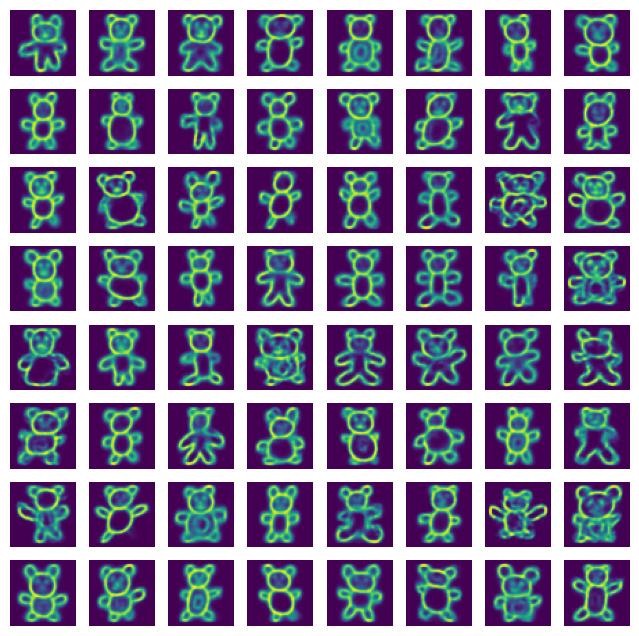

In [13]:
model.eval()

with torch.no_grad():
    z = torch.randn(8 * 8, z_dim).to(device)
    x_gen = model.decoder(z).view(-1, IMG_WIDTH, IMG_WIDTH).cpu()

draw_images(x_gen, 8, 8)